In [1]:
#Importing libraries
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import ast 

#Loading data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

d:\Anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Unnest the 'job_skills' list so each skill has its own row (multiplies rows per job)
df_exploded = df.explode('job_skills').copy()

# Count occurrences of each skill grouped by the job title
skill_count = df_exploded.groupby(['job_skills', 'job_title_short']).size()

# Convert the resulting Series into a readable DataFrame with a proper count column
df_skill_count = skill_count.reset_index(name='skill_count')

# Sort the results so the most frequent skills appear at the top
df_skill_count.sort_values(by='skill_count', ascending=False, inplace=True)

# Display the final ranked list of skills per job title
df_skill_count

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
293,codecommit,Business Analyst,1
2233,xamarin,Machine Learning Engineer,1
1087,mlr,Machine Learning Engineer,1


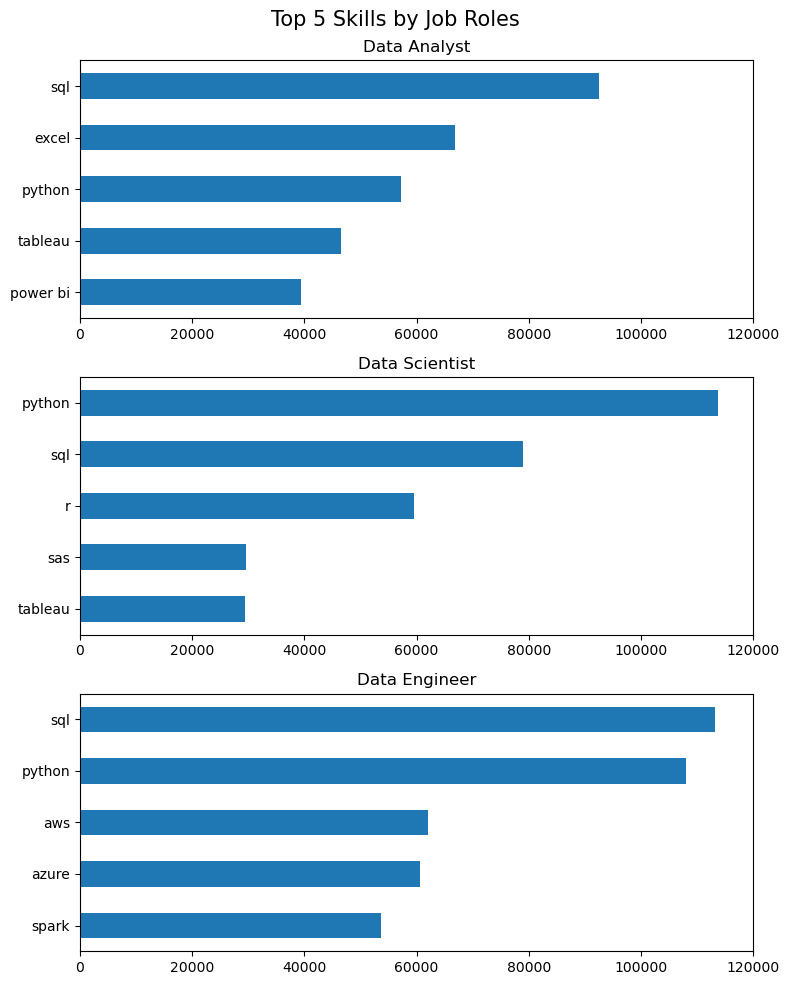

In [3]:
# Define the subset of job titles to compare
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']

# Create a figure with 3 subplots stacked vertically (one for each role)
fig, ax = plt.subplots(3, 1, figsize=(8, 10))

for i, job_title in enumerate(job_titles):
    # Filter the pre-sorted skill count DataFrame for the specific job title
    # Selecting the Top 5 most frequent skills
    df_plot = df_skill_count[df_skill_count['job_title_short'] == job_title].head(5)
    
    # Generate a horizontal bar chart
    # .invert_yaxis() ensures the #1 skill is at the top of the chart
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=ax[i], title=job_title).invert_yaxis()
    
    # Clean up aesthetics: remove redundant y-labels and hide the legend
    ax[i].set_ylabel('')
    ax[i].legend().set_visible(False)
    
    # Standardize the X-axis scale across all plots for an "apples-to-apples" comparison
    ax[i].set_xlim(0, 120000)

# Add a centralized global title and adjust spacing to prevent label clipping
fig.suptitle('Top 5 Skills by Job Roles', fontsize=15)
fig.tight_layout()
plt.show()